<a href="https://colab.research.google.com/github/Jaseem524/clg-final-project-/blob/main/Customer_Buying_Trends_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
!pip install pyspark -q
!pip install graphviz -q
!apt-get install graphviz -y -qq

In [28]:
from google.colab import files
uploaded = files.upload()

Saving Shopping Trends And Customer Behaviour Dataset.csv to Shopping Trends And Customer Behaviour Dataset (1).csv


In [29]:
from pyspark.sql import SparkSession
from pyspark.sql import Row
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from graphviz import Digraph

In [30]:
spark = SparkSession.builder \
    .appName("CustomerTrendPrediction") \
    .getOrCreate()

print("Spark Started Successfully")


Spark Started Successfully


In [31]:
data = [
    Row(age=21, salary=25000, purchased=0),
    Row(age=24, salary=30000, purchased=0),
    Row(age=28, salary=45000, purchased=1),
    Row(age=32, salary=52000, purchased=1),
    Row(age=36, salary=62000, purchased=1),
    Row(age=23, salary=27000, purchased=0),
    Row(age=40, salary=70000, purchased=1),
    Row(age=27, salary=39000, purchased=0)
]

df = spark.createDataFrame(data)

print("Original Dataset")
df.show()

Original Dataset
+---+------+---------+
|age|salary|purchased|
+---+------+---------+
| 21| 25000|        0|
| 24| 30000|        0|
| 28| 45000|        1|
| 32| 52000|        1|
| 36| 62000|        1|
| 23| 27000|        0|
| 40| 70000|        1|
| 27| 39000|        0|
+---+------+---------+



In [32]:
assembler = VectorAssembler(
    inputCols=["age", "salary"],
    outputCol="features"
)

dataset = assembler.transform(df)
dataset = dataset.select("features", "purchased")

print("Prepared Dataset")
dataset.show()

Prepared Dataset
+--------------+---------+
|      features|purchased|
+--------------+---------+
|[21.0,25000.0]|        0|
|[24.0,30000.0]|        0|
|[28.0,45000.0]|        1|
|[32.0,52000.0]|        1|
|[36.0,62000.0]|        1|
|[23.0,27000.0]|        0|
|[40.0,70000.0]|        1|
|[27.0,39000.0]|        0|
+--------------+---------+



In [33]:
train_data, test_data = dataset.randomSplit([0.8, 0.2], seed=10)

print("Train and Test Data Ready")

Train and Test Data Ready


In [34]:
layers = [2, 4, 3, 2]

mlp = MultilayerPerceptronClassifier(
    layers=layers,
    labelCol="purchased",
    featuresCol="features",
    maxIter=100
)

model = mlp.fit(train_data)

print("Model Training Completed")

Model Training Completed


In [35]:
loaded_predictions = model.transform(test_data)

print("Loaded Model Predictions")
loaded_predictions.select("purchased", "prediction").show()

print("Prediction Distribution")
loaded_predictions.groupBy("prediction").count().show()

Loaded Model Predictions
+---------+----------+
|purchased|prediction|
+---------+----------+
|        0|       1.0|
|        1|       1.0|
+---------+----------+

Prediction Distribution
+----------+-----+
|prediction|count|
+----------+-----+
|       1.0|    2|
+----------+-----+



In [36]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="purchased",
    predictionCol="prediction"
)

accuracy = evaluator.setMetricName("accuracy").evaluate(predictions)
precision = evaluator.setMetricName("weightedPrecision").evaluate(predictions)
recall = evaluator.setMetricName("weightedRecall").evaluate(predictions)

print("Accuracy :", round(accuracy,2))
print("Precision:", round(precision,2))
print("Recall   :", round(recall,2))

Accuracy : 0.5
Precision: 0.25
Recall   : 0.5


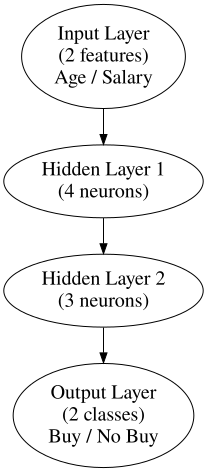

In [37]:
from graphviz import Digraph

dot = Digraph(format='png')
dot.attr(rankdir='TB', size='8,10')

# Node Style
dot.attr('node', shape='ellipse', style='solid', fontsize='20')

# Layers
dot.node('Input', 'Input Layer\n(2 features)\nAge / Salary')
dot.node('H1', 'Hidden Layer 1\n(4 neurons)')
dot.node('H2', 'Hidden Layer 2\n(3 neurons)')
dot.node('Output', 'Output Layer\n(2 classes)\nBuy / No Buy')

# Connections
dot.edge('Input', 'H1')
dot.edge('H1', 'H2')
dot.edge('H2', 'Output')

# Show Diagram
dot